In [26]:
# %pip install -q seaborn

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt
import warnings
from scipy.stats import pearsonr # type: ignore


warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

def show_layout():
    plt.figure(figsize=(10, 7))
    plt.tight_layout()
    plt.show()

### Medical Insurance Cost – EDA & Visualization (Self Evaluation)

In [28]:
try:
    FILE_PATH = r"C:\Users\AYO_AYO\Desktop\Machine-Learning-Bootcamp\CSV-Excel\insurance.csv"
    med_insurance_df = pd.read_csv(FILE_PATH)
    print("Dataset loaded succesfully")
except FileNotFoundError as e:
    print("Dataset not found", e)

Dataset loaded succesfully


In [29]:
print(med_insurance_df.head())
print(med_insurance_df.shape)
print(med_insurance_df.info())
print(med_insurance_df.describe())
print(med_insurance_df.isna().sum())
print(med_insurance_df.nunique())
print(med_insurance_df.duplicated().sum())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  13

In [30]:
numerical_cols = med_insurance_df.select_dtypes([np.number]).columns.to_list()
categorical_cols = [col for col in med_insurance_df.columns if col not in numerical_cols]

print(f"Numerical Features: {numerical_cols}")
print(f"Categorical Features: {categorical_cols}")

Numerical Features: ['age', 'bmi', 'children', 'charges']
Categorical Features: ['sex', 'smoker', 'region']


In [31]:
numerical_df = med_insurance_df[numerical_cols].dropna()
categorical_df = med_insurance_df[categorical_cols].dropna()

**Numerical Feature Distribution**

In [32]:
numerical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [33]:
numerical_df["age"].value_counts().sort_values(ascending=False)[:5]

age
18    69
19    68
46    29
52    29
50    29
Name: count, dtype: int64

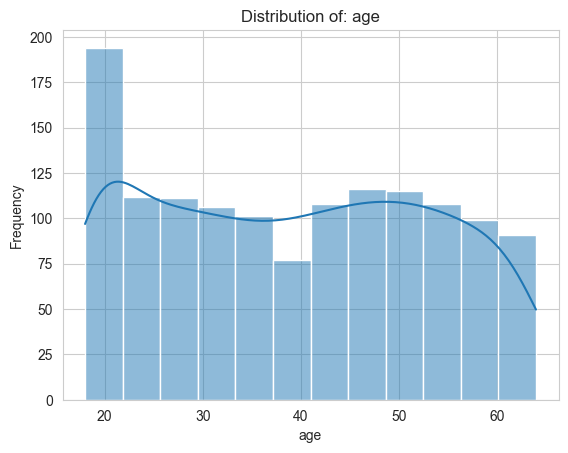

<Figure size 1000x700 with 0 Axes>

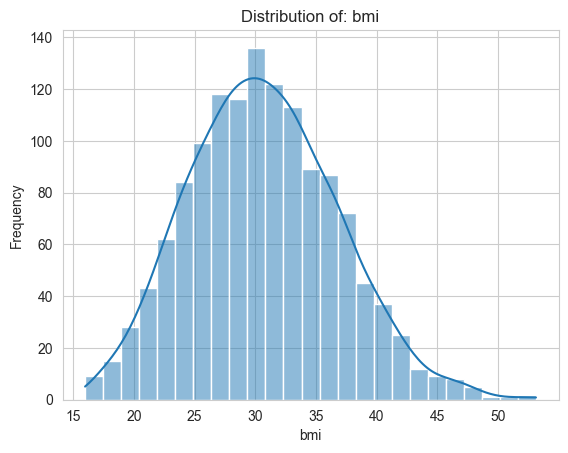

<Figure size 1000x700 with 0 Axes>

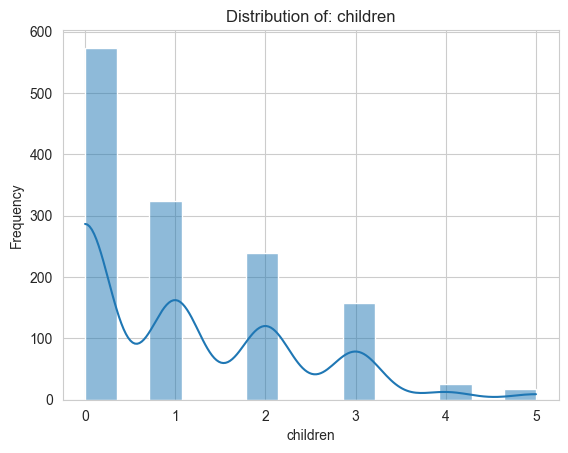

<Figure size 1000x700 with 0 Axes>

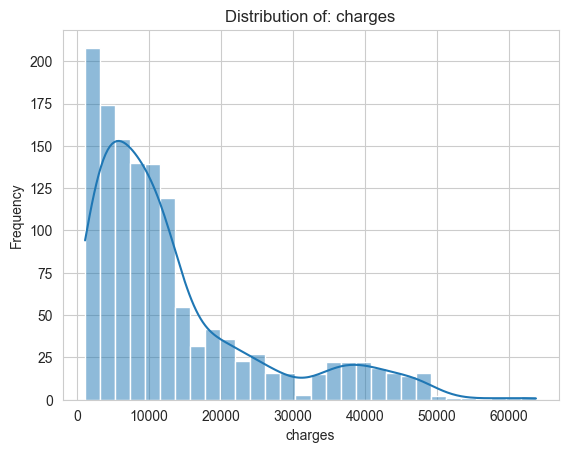

<Figure size 1000x700 with 0 Axes>

In [34]:
for col in numerical_df:
    sns.histplot(data=numerical_df, x=col, kde=True)
    plt.title(f"Distribution of: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    show_layout()

**Catgorical Features**

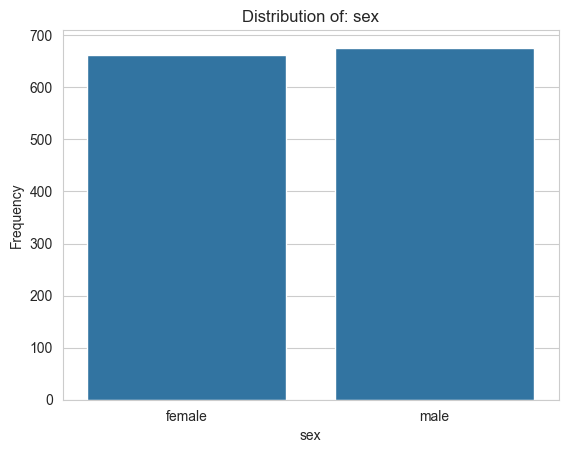

<Figure size 1000x700 with 0 Axes>

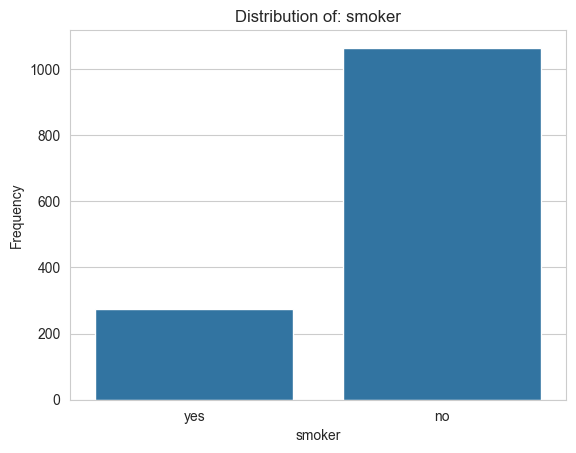

<Figure size 1000x700 with 0 Axes>

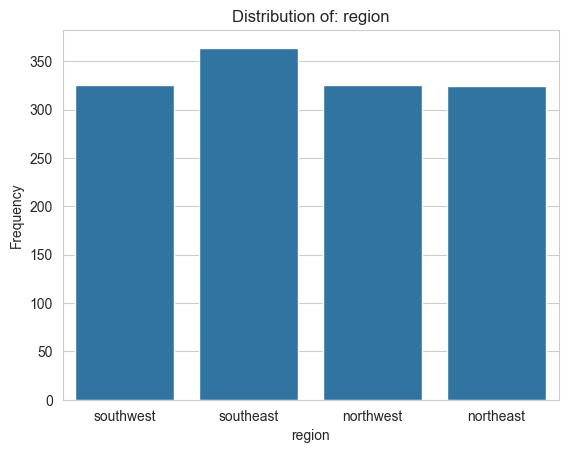

<Figure size 1000x700 with 0 Axes>

In [43]:
for col in categorical_df:
    sns.countplot(data=categorical_df, x=col)
    plt.title(f"Distribution of: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    show_layout()

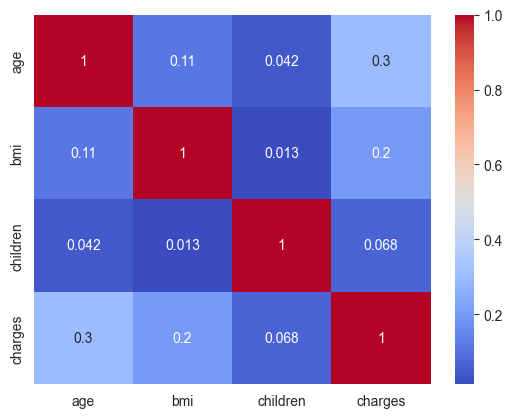

<Figure size 1000x700 with 0 Axes>

In [ ]:
# Study relationships between features and insurance charges
# Value	        Meaning
# +1	        Perfect positive relationship
# +0.7 to +1	Strong
# +0.3 to +0.7	Moderate
# 0 to +0.3	    Weak
# 0	            No relationship

correlation = numerical_df.corr()
sns.heatmap(data=correlation, cmap="coolwarm", annot=True)
show_layout()

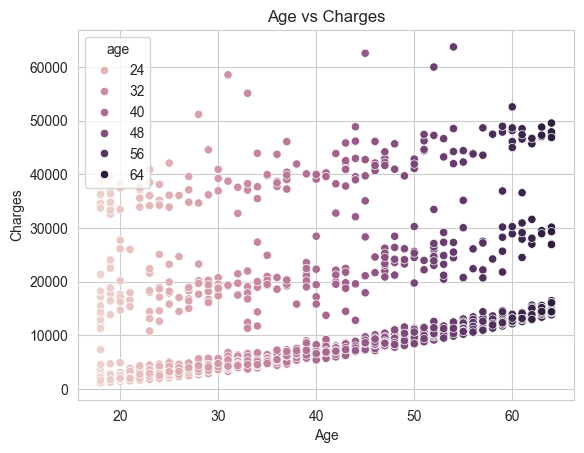

<Figure size 1000x700 with 0 Axes>

In [54]:
sns.scatterplot(data=numerical_df, x=numerical_df["age"], y=numerical_df["charges"], hue="age")
plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
show_layout()